In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [22]:
df = pd.read_csv("/content/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [24]:
df.shape

(200, 5)

In [25]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [26]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [36]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


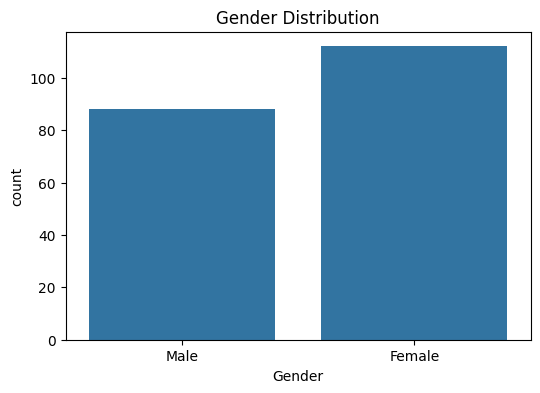

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

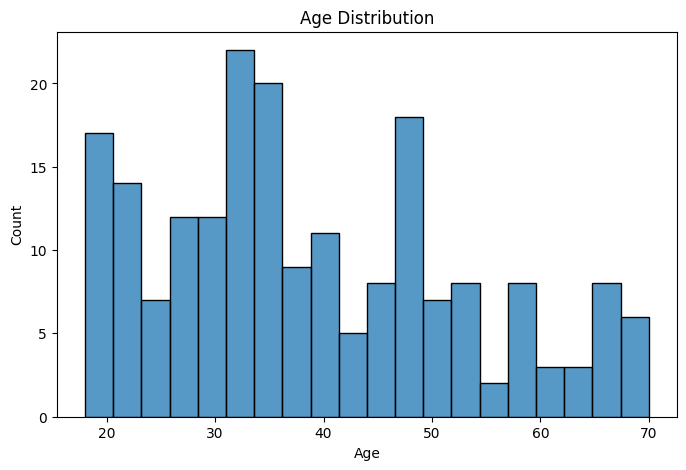

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")

plt.show()

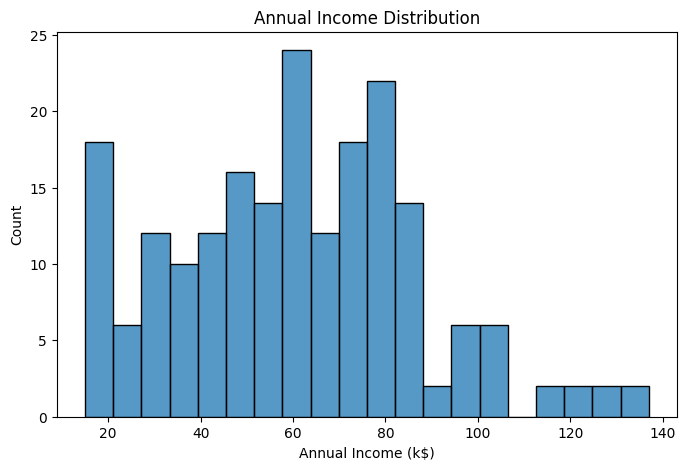

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20)

plt.title("Annual Income Distribution")

plt.show()

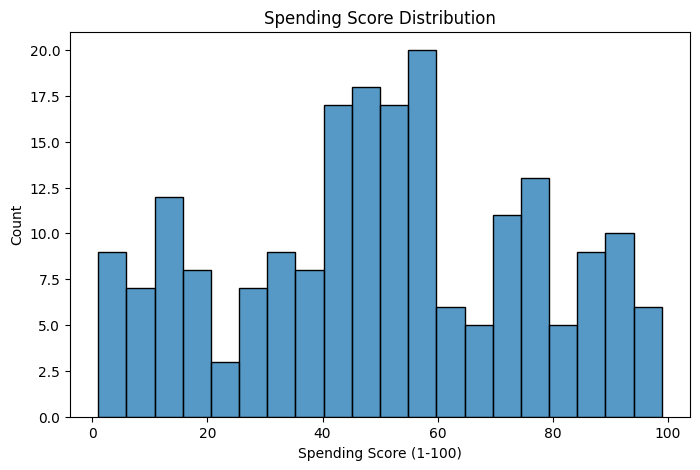

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20)

plt.title("Spending Score Distribution")

plt.show()

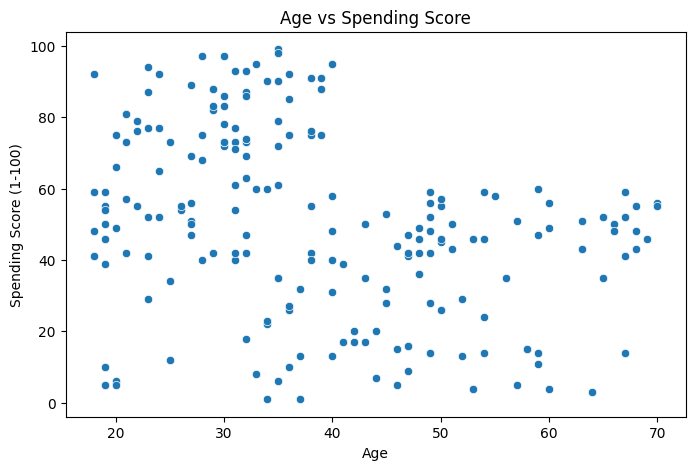

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Age vs Spending Score")

plt.show()

In [46]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [31]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


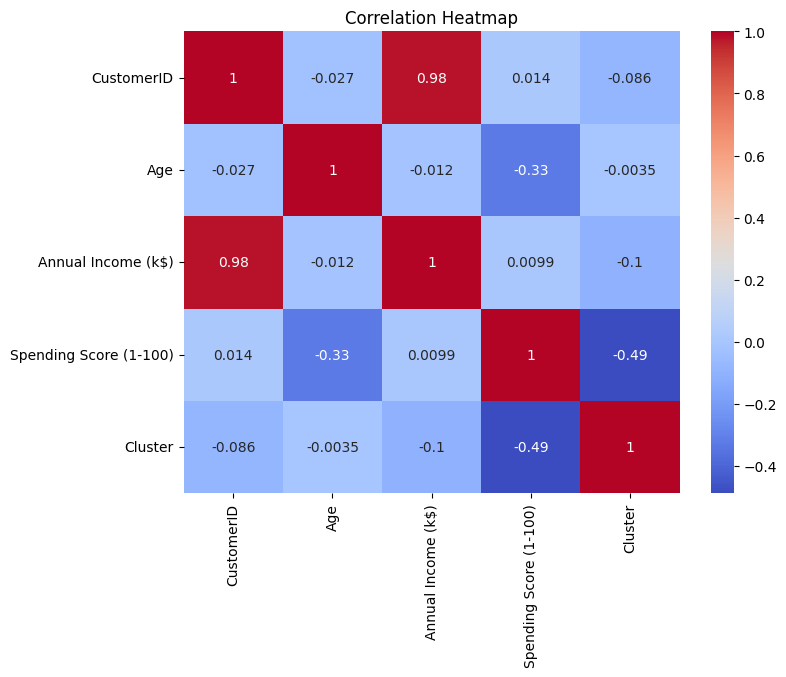

In [47]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [51]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

In [50]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

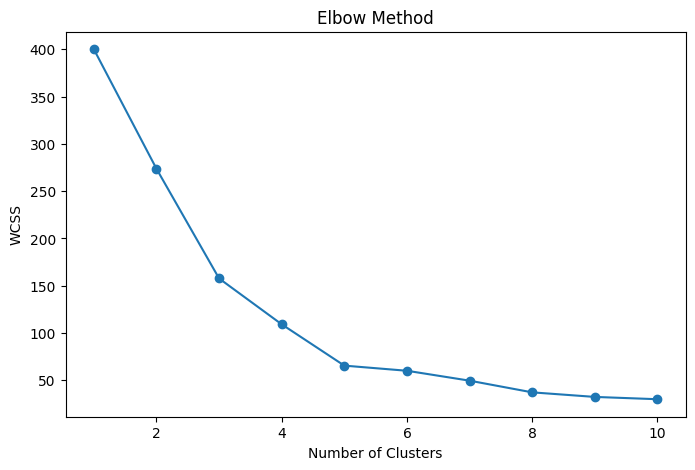

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [53]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

y_kmeans = kmeans.fit_predict(X_scaled)

In [54]:
df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [55]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [56]:
score = silhouette_score(
    X_scaled,
    y_kmeans
)

print("Silhouette Score :", score)

Silhouette Score : 0.5546571631111091


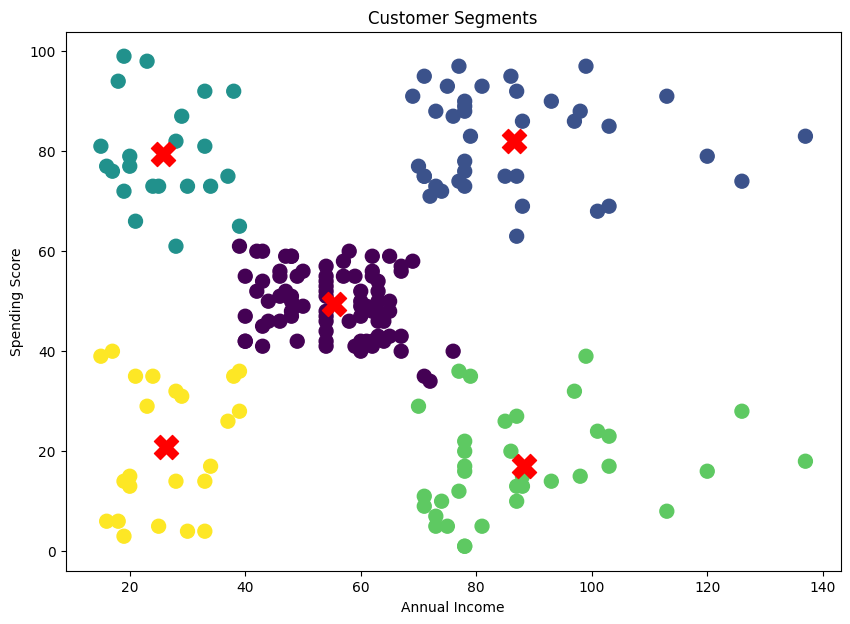

In [17]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap='viridis',
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    s=300,
    marker='X'
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segments")

plt.show()

In [57]:
cluster_summary = df.groupby('Cluster').agg({

    'Age':'mean',

    'Annual Income (k$)':'mean',

    'Spending Score (1-100)':'mean'

})

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


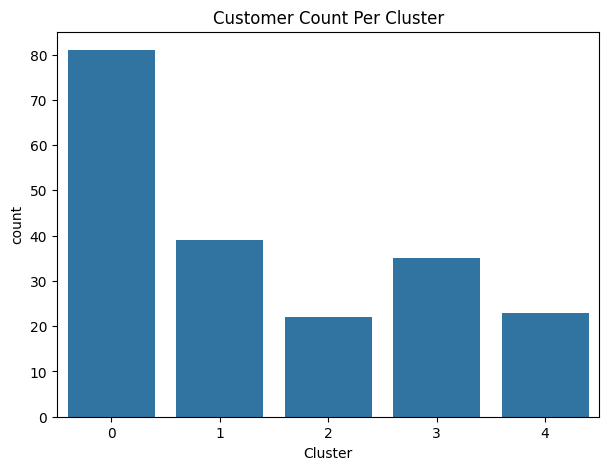

In [58]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Cluster',
    data=df
)

plt.title("Customer Count Per Cluster")

plt.show()

In [59]:
df.to_csv(
    "Customer_Segmentation_Output.csv",
    index=False
)

print("Output Saved Successfully")

Output Saved Successfully


In [60]:
for cluster in sorted(df['Cluster'].unique()):

    print("="*50)

    print("Cluster :", cluster)

    print(df[df['Cluster']==cluster][[
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]].describe())

Cluster : 0
             Age  Annual Income (k$)  Spending Score (1-100)
count  81.000000           81.000000               81.000000
mean   42.716049           55.296296               49.518519
std    16.447822            8.988109                6.530909
min    18.000000           39.000000               34.000000
25%    27.000000           48.000000               44.000000
50%    46.000000           54.000000               50.000000
75%    54.000000           62.000000               55.000000
max    70.000000           76.000000               61.000000
Cluster : 1
             Age  Annual Income (k$)  Spending Score (1-100)
count  39.000000           39.000000               39.000000
mean   32.692308           86.538462               82.128205
std     3.728650           16.312485                9.364489
min    27.000000           69.000000               63.000000
25%    30.000000           75.500000               74.500000
50%    32.000000           79.000000               83.000000


In [61]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [62]:
df.to_csv(
    "Customer_Segmentation_Output.csv",
    index=False
)

In [63]:
print("""
Customer Segmentation Successfully Completed

Algorithm Used : K-Means Clustering

Total Clusters : 5

Features Used :
1. Annual Income
2. Spending Score

Output Generated :
Customer Segments with Insights
""")


Customer Segmentation Successfully Completed

Algorithm Used : K-Means Clustering

Total Clusters : 5

Features Used :
1. Annual Income
2. Spending Score

Output Generated :
Customer Segments with Insights



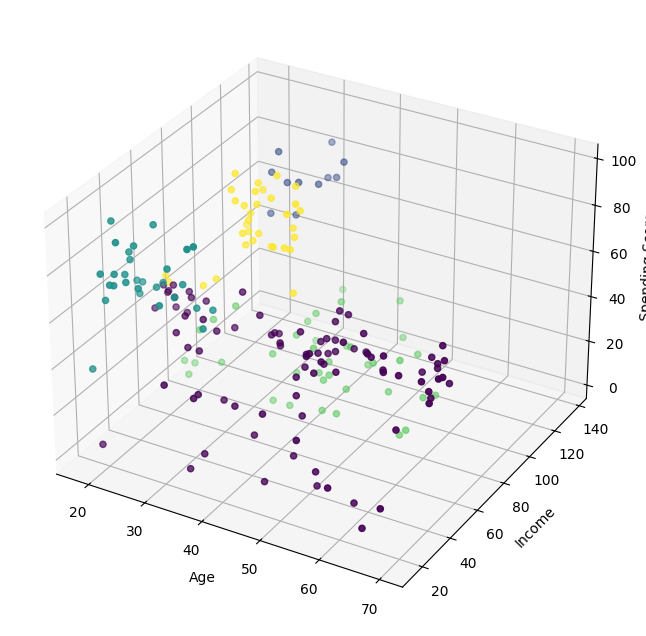

In [64]:
from mpl_toolkits.mplot3d import Axes3D

X_3d = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

kmeans_3d = KMeans(n_clusters=5, random_state=42)
df['Cluster_3D'] = kmeans_3d.fit_predict(X_3d)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster_3D']
)

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Spending Score')

plt.show()

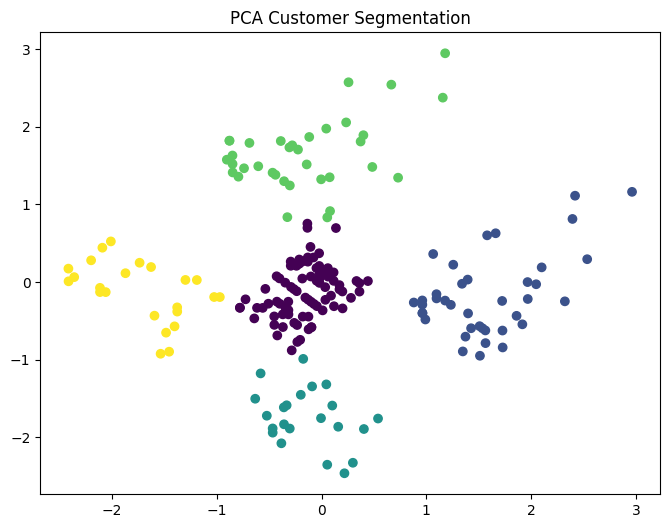

In [65]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_kmeans,
    cmap='viridis'
)

plt.title("PCA Customer Segmentation")
plt.show()

In [66]:
pd.crosstab(
    df['Cluster'],
    df['Gender']
)

Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


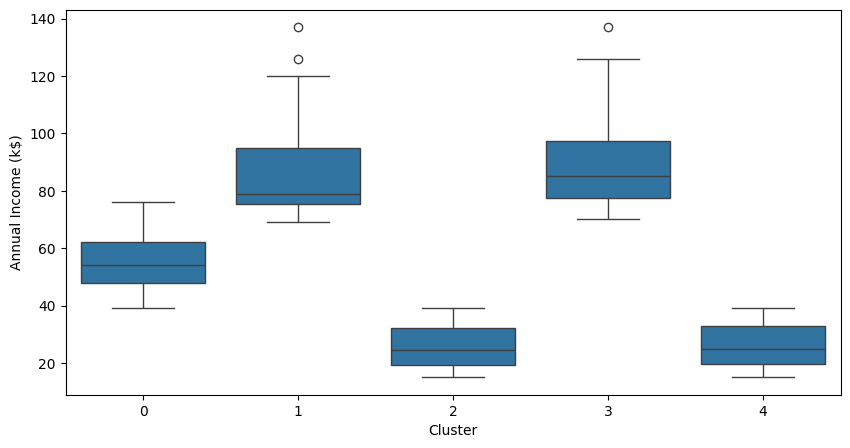

In [67]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Cluster',
    y='Annual Income (k$)',
    data=df
)

plt.show()